# Session 4, Notebook 1: Analytic six-cohort OLG, DEQN (Persistent Simulation)

**Course:** Deep Learning for Solving Dynamic Models - University of Padova, 23-24 September 2026  
**Session:** Day 1, 14:25 - 15:25 - OLG models with DEQNs  
**Slides:** `04_OLG_Models_DEQNs.pdf`, Part II  
**Notebook role:** core  
**Author:** Simon Scheidegger (HEC, University of Lausanne)  

---

The six-cohort overlapping-generations model of Krueger and Kübler (2004): log utility, stochastic Cobb–Douglas production, four i.i.d. TFP and depreciation states, and a closed-form age-specific savings rate against which the trained policy is validated.

The training states are simulated under the current policy network: each training segment starts from the terminal states of the previous one, so the network is trained on its own ergodic set. `04_04_OLG_Analytic_DEQN_exogenous.ipynb` trains the same model on states drawn from a fixed box instead.

**The stored outputs are a `teaching` run**, which is also the committed default: about eleven minutes on a laptop CPU. They reproduce the closed-form savings rates to $1\times10^{-5}$ cohort by cohort, with a mean relative Euler error of $2.5\times10^{-4}$ on out-of-sample simulated states. In class, set `RUN_MODE` to `"smoke"` in the next cell for a short run whose numbers are not converged.

In [1]:
RUN_MODE = "teaching"  # one of: "smoke", "teaching", "production"
SEED = 0
SAVE_FIGURES = False  # True writes the slide figures to ../../slides/figures/ (or $OLG_FIGURE_DIR)


In [2]:
SAMPLING_MODE = "simulation"

# ============================================================
# Imports, random seeds, and main switches
# ============================================================
import math
import time

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["font.size"] = 12

np.random.seed(SEED)
tf.random.set_seed(SEED)
rng = np.random.default_rng(SEED)

# ------------------------------------------------------------
# Training-budget switch
# ------------------------------------------------------------
# smoke      : quick code check
# teaching   : classroom/laptop run
# production : paper-style scale; intended for GPU/HPC runs
MODE = RUN_MODE                   # mirrors the run-mode switch in the first cell

if MODE == "smoke":
    NUM_SEGMENTS = 25
    N_TRAJECTORIES = 16
    SIMULATION_LENGTH = 16
    PASSES_PER_SEGMENT = 1
    MONITOR_EVERY = 5
    EVAL_TRACKS = 16
    EVAL_BURN_IN = 16
    EVAL_LENGTH = 32
    HIDDEN_UNITS_1 = 64
    HIDDEN_UNITS_2 = 32
    TRAINING_SCHEDULE = [
        dict(until=NUM_SEGMENTS, learning_rate=3e-4, batch_size=128),
    ]
elif MODE == "teaching":
    # The preset the stored outputs come from.  Two stages: 1e-4 to find the solution, then
    # 1e-5 to sharpen the residuals.  About eleven minutes on a laptop CPU with simulation,
    # about three and a half with exogenous sampling.
    NUM_SEGMENTS = 1201
    N_TRAJECTORIES = 32
    SIMULATION_LENGTH = 32
    PASSES_PER_SEGMENT = 4
    MONITOR_EVERY = 10
    EVAL_TRACKS = 32
    EVAL_BURN_IN = 64
    EVAL_LENGTH = 128
    HIDDEN_UNITS_1 = 100
    HIDDEN_UNITS_2 = 50
    TRAINING_SCHEDULE = [
        dict(until=700, learning_rate=1e-4, batch_size=512),
        dict(until=NUM_SEGMENTS, learning_rate=1e-5, batch_size=512),
    ]
elif MODE == "production":
    # Appendix A.8 of the DEQN paper uses two hidden layers with 100 and 50
    # ReLU units, 12,800 states per episode, 20 epochs per episode, and a
    # long training run.  This preset keeps that scale.
    NUM_SEGMENTS = 10_000
    N_TRAJECTORIES = 100
    SIMULATION_LENGTH = 128
    PASSES_PER_SEGMENT = 20
    MONITOR_EVERY = 100
    EVAL_TRACKS = 128
    EVAL_BURN_IN = 256
    EVAL_LENGTH = 256
    HIDDEN_UNITS_1 = 100
    HIDDEN_UNITS_2 = 50
    TRAINING_SCHEDULE = [
        dict(until=NUM_SEGMENTS, learning_rate=1e-5, batch_size=640),
    ]
else:
    raise ValueError(f"Unknown MODE: {MODE}")

STATES_PER_SEGMENT = N_TRAJECTORIES * SIMULATION_LENGTH
SHUFFLE_STATES_WITHIN_SEGMENT = True
OPTIMIZER_NAME = "Adam"
CLIP_NORM = 10.0


E0000 00:00:1788897494.497633  213512 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788897494.504145  213512 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# The feasibility penalties are zero under the sigmoid head; they are kept so
# that the residual code matches the benchmark notebooks.
EULER_WEIGHT = 1.0
PENALTY_WEIGHT = 10.0

# Monitoring on a fixed set of held-out states, as in the IRBC notebook.  The network has
# no calendar-time input, so same-state repeatability is exact; the useful check
# is whether the learned function is still moving across SGD updates.
TIME_INVARIANCE_ANCHOR_STATES = 256 if MODE == "smoke" else 2048
TIME_INVARIANCE_TOL_RMS = 1.0e-3
TIME_INVARIANCE_TOL_MAX = 1.0e-2

print(f"TensorFlow version: {tf.__version__}")
print(f"SAMPLING_MODE = {SAMPLING_MODE}")
print(f"MODE = {MODE}")
print(f"states per segment = {STATES_PER_SEGMENT}")
print(f"hidden units = ({HIDDEN_UNITS_1}, {HIDDEN_UNITS_2})")

# ------------------------------------------------------------
# Figure export for the lecture slides (off by default)
# ------------------------------------------------------------
import os
FIGURE_DIR = os.environ.get("OLG_FIGURE_DIR", os.path.join("..", "..", "slides", "figures"))

def savefig(fig, name):
    """Write a figure for the slides when SAVE_FIGURES is on; otherwise a no-op."""
    if SAVE_FIGURES:
        os.makedirs(FIGURE_DIR, exist_ok=True)
        fig.savefig(os.path.join(FIGURE_DIR, name), bbox_inches="tight")


TensorFlow version: 2.18.0
SAMPLING_MODE = simulation
MODE = teaching
states per segment = 1024
hidden units = (100, 50)


## 1. Economic parameters

---

The Krueger–Kübler (2004) calibration: $A = 6$ overlapping cohorts, log utility, Cobb–Douglas production with capital share $\alpha = 0.3$, discount factor $\beta = 0.7$, labor supplied by cohort 1 only, and four i.i.d. aggregate states combining TFP $\eta \in \{0.95, 1.05\}$ with depreciation $\delta \in \{0.5, 0.9\}$, each with probability $1/4$.

## 2. Where the closed form comes from

---

Write $\text{inc}_t^h = r_t k_t^h + \ell^h w_t$ for cohort $h$'s cash-on-hand. Work backwards from the last period of life. Cohort $A$ has no tomorrow and consumes all of $\text{inc}$. Cohort $A-1$ solves $\max_a \ln(\text{inc}-a) + \beta\,\mathbb{E}\ln(r'a)$; because $\ln(r'a) = \ln r' + \ln a$ the return drops out of the first-order condition, $1/(\text{inc}-a) = \beta/a$, so $a = \tfrac{\beta}{1+\beta}\text{inc}$ and the continuation value is $(1+\beta)\ln \text{inc} + \text{const}$. Repeating the step, cohort $h$ with $A-h$ periods ahead saves the fraction

$$
  \beta_h \;=\; \frac{\beta + \beta^2 + \cdots + \beta^{A-h}}{1 + \beta + \cdots + \beta^{A-h}}
  \;=\; \beta\,\frac{1 - \beta^{A-h}}{1 - \beta^{A-h+1}}
$$

of cash-on-hand, a number that depends on age only.

Two assumptions are responsible. Log utility separates $\mathbb{E}\ln(r'a)$ into $\ln a + \mathbb{E}\ln r'$, so the savings rate is the same for any distribution of returns; persistent shocks would not change this. And no cohort has future labor income, since only the newborn works and only once, so cash-on-hand is the household's entire state and there is nothing to borrow against; the constraint $a \ge 0$ never binds. The 56-cohort benchmark of the slides drops both, with CRRA utility and a hump-shaped labor profile, and needs a numerical solver with explicit multipliers.

=== Analytic OLG parameters ===
N_AGES = 6, raw state dim = 7, feature dim = 40
policy dim = 5
BETA = 0.7, GAMMA = 1.0, ALPHA = 0.3
TFP: [0.95 1.05 0.95 1.05]
Depreciation: [0.5 0.5 0.9 0.9]
Transition matrix PI:
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]
Labor endowment: [1. 0. 0. 0. 0. 0.]
Closed-form savings rates used for diagnostics:
  age 1: 0.659999
  age 2: 0.639393
  age 3: 0.605211
  age 4: 0.543379
  age 5: 0.411765


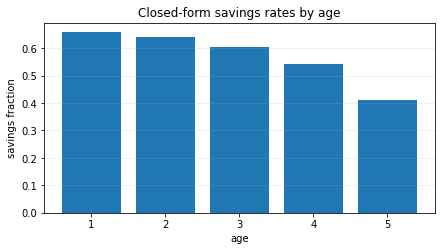

In [4]:
# ============================================================
# Analytic OLG parameters
# ============================================================
N_AGES = 6
NUM_SHOCKS = 4
AGES = np.arange(1, N_AGES + 1)

# Preferences and technology.  The closed-form benchmark requires log utility.
BETA = 0.70
GAMMA = 1.0
ALPHA = 0.30

# Aggregate shocks: order is
#   0 = low TFP, low depreciation
#   1 = high TFP, low depreciation
#   2 = low TFP, high depreciation
#   3 = high TFP, high depreciation
TFP = np.array([0.95, 1.05, 0.95, 1.05], dtype=np.float32)
DEPR = np.array([0.50, 0.50, 0.90, 0.90], dtype=np.float32)
PI = np.ones((NUM_SHOCKS, NUM_SHOCKS), dtype=np.float32) / NUM_SHOCKS
PI_CUM = np.cumsum(PI, axis=1)

# Labor endowment: only the newborn cohort supplies labor.  Aggregate labor is 1.
LABOR = np.zeros(N_AGES, dtype=np.float32)
LABOR[0] = 1.0
L_TOTAL = float(np.sum(LABOR))

# Closed-form savings rates.  These are used only for diagnostics, never in the
# training loss or in the construction of simulated training states.
BETA_VEC = BETA * (1.0 - BETA ** (N_AGES - 1 - np.arange(N_AGES - 1))) / (
    1.0 - BETA ** (N_AGES - np.arange(N_AGES - 1))
)

# Tensor constants
TFP_TF = tf.constant(TFP.reshape(NUM_SHOCKS, 1), dtype=tf.float32)
DEPR_TF = tf.constant(DEPR.reshape(NUM_SHOCKS, 1), dtype=tf.float32)
PI_TF = tf.constant(PI, dtype=tf.float32)
LABOR_TF = tf.constant(LABOR.reshape(1, N_AGES), dtype=tf.float32)
L_TOTAL_TF = tf.constant(L_TOTAL, dtype=tf.float32)
BETA_VEC_TF = tf.constant(BETA_VEC.reshape(1, N_AGES - 1), dtype=tf.float32)

RAW_STATE_DIM = 1 + N_AGES       # [z, k_1,...,k_N]
FEATURE_DIM = 1 + NUM_SHOCKS + 2 + 5 + 4 * N_AGES + NUM_SHOCKS
N_CHOICES = N_AGES - 1
POLICY_DIM = N_CHOICES           # savings a^1,...,a^{N-1}

print("=== Analytic OLG parameters ===")
print(f"N_AGES = {N_AGES}, raw state dim = {RAW_STATE_DIM}, feature dim = {FEATURE_DIM}")
print(f"policy dim = {POLICY_DIM}")
print(f"BETA = {BETA}, GAMMA = {GAMMA}, ALPHA = {ALPHA}")
print("TFP:", TFP)
print("Depreciation:", DEPR)
print("Transition matrix PI:")
print(PI)
print("Labor endowment:", LABOR)
print("Closed-form savings rates used for diagnostics:")
for age, rate in zip(AGES[:-1], BETA_VEC):
    print(f"  age {age}: {rate:.6f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(AGES[:-1], BETA_VEC)
ax.set_title("Closed-form savings rates by age")
ax.set_xlabel("age")
ax.set_ylabel("savings fraction")
ax.grid(alpha=0.25, axis="y")
plt.show()


## 3. State and network inputs

---

The minimal state is the shock indicator and the cohort capital vector, $1 + A = 7$ numbers. The network is given an extended input that also carries quantities computable from the state: the one-hot shock, the shock values $(\eta_t, \delta_t)$, the aggregates $(K_t, L_t, r_t, w_t, Y_t)$, each cohort's capital, financial income $r_t k_t^h$, labor income $\ell^h w_t$ and cash-on-hand $\text{inc}_t^h$, and the row $\boldsymbol{\pi}(z_t)$ of transition probabilities. That is

$$
  \dim(\mathbf{s}_t) = \underbrace{1 + 4 + 2 + 5}_{\text{aggregate}} + \underbrace{4A}_{\text{per cohort}} + \underbrace{4}_{\boldsymbol{\pi}(z_t)} = 16 + 4A = 40
$$

for $A = 6$. The equilibrium is unchanged; only the network's input is enriched.

In [5]:
# ============================================================
# State representation, firm prices, and network features
# ============================================================
EPS = 1.0e-8
CONSUMPTION_FLOOR = 1.0e-8

# Feature scales.  These are numerical normalizations, not equilibrium targets.
ASSET_SCALE = 1.0
AGG_K_SCALE = max(1.0, 0.4 * N_AGES)
AGG_L_SCALE = max(1.0, L_TOTAL)
PRICE_SCALE = 1.0
OUTPUT_SCALE = 1.0

# Broad feasible boxes for exogenous training states and initial simulation
# heads.  These draws deliberately do not use a lifecycle shape, steady state,
# or the closed-form solution.
EXOGENOUS_K_LOW = 0.005
EXOGENOUS_K_HIGH = 1.00
INITIAL_K_LOW = 0.005
INITIAL_K_HIGH = 1.00

EMERGENCY_REPAIR_BAD_STATES = True
# Runaway guard, tied to the sampling box: a simulated state with aggregate capital
# above EXOGENOUS_K_HIGH * N_AGES is resampled.  It never fires on a healthy run.
SIM_REPAIR_AGG_K_MIN = 1.0e-4
SIM_REPAIR_AGG_K_MAX = EXOGENOUS_K_HIGH * N_AGES
SIM_REPAIR_ABS_K_MAX = EXOGENOUS_K_HIGH * N_AGES


def unpack_state(states):
    """Return integer shock indices and capital holdings."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    z = tf.cast(tf.round(states[:, 0]), tf.int32)
    k = states[:, 1:1 + N_AGES]
    return z, k


def assemble_states_tf(z, k):
    """Assemble a TensorFlow raw state array."""
    z = tf.cast(tf.reshape(z, [-1, 1]), tf.float32)
    return tf.concat([z, tf.cast(k, tf.float32)], axis=1)


def assemble_states_np(z, k):
    """Assemble a NumPy raw state array."""
    return np.concatenate([
        np.asarray(z, dtype=np.float32).reshape(-1, 1),
        np.asarray(k, dtype=np.float32),
    ], axis=1).astype(np.float32)


def firm_prices_from_components(K, eta, depr):
    """Return r, w, and aggregate output for the analytic OLG production function."""
    K_safe = tf.maximum(tf.cast(K, tf.float32), EPS)
    eta = tf.cast(eta, tf.float32)
    depr = tf.cast(depr, tf.float32)
    L = tf.ones_like(K_safe) * L_TOTAL_TF
    r = ALPHA * eta * tf.pow(K_safe, ALPHA - 1.0) * tf.pow(L, 1.0 - ALPHA) + (1.0 - depr)
    w = (1.0 - ALPHA) * eta * tf.pow(K_safe, ALPHA) * tf.pow(L, -ALPHA)
    Y = eta * tf.pow(K_safe, ALPHA) * tf.pow(L, 1.0 - ALPHA) + (1.0 - depr) * K_safe
    return r, w, Y


def state_prices(states):
    """Prices and aggregates implied by the raw state."""
    z, k = unpack_state(states)
    eta = tf.gather(TFP_TF, z)
    depr = tf.gather(DEPR_TF, z)
    K = tf.reduce_sum(k, axis=1, keepdims=True)
    r, w, Y = firm_prices_from_components(K, eta, depr)
    return K, r, w, Y, eta, depr


def current_income(states):
    """Income before current savings choices: r k + w l."""
    _, k = unpack_state(states)
    K, r, w, Y, eta, depr = state_prices(states)
    financial_income = r * k
    labor_income = w * LABOR_TF
    income = financial_income + labor_income
    return income, labor_income, financial_income, K, r, w, Y, eta, depr


def network_features(states):
    """Build the augmented input used by the neural net.

    The raw state remains [z, k].  The augmentation supplies the same type of
    redundant economic information used in the larger OLG notebook: shock
    indicators, transition probabilities, prices, capital, financial income,
    labor income, and total income.
    """
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    z, k = unpack_state(states)
    income, labor_income, financial_income, K, r, w, Y, eta, depr = current_income(states)
    z_float = tf.cast(tf.reshape(z, [-1, 1]), tf.float32)
    one_hot_z = tf.one_hot(z, NUM_SHOCKS, dtype=tf.float32)
    transition_row = tf.gather(PI_TF, z)
    features = tf.concat([
        z_float / max(1.0, NUM_SHOCKS - 1.0),
        one_hot_z,
        eta,
        depr,
        K / AGG_K_SCALE,
        tf.ones_like(K) * (L_TOTAL / AGG_L_SCALE),
        r / PRICE_SCALE,
        w / PRICE_SCALE,
        Y / OUTPUT_SCALE,
        k / ASSET_SCALE,
        financial_income / ASSET_SCALE,
        labor_income / ASSET_SCALE,
        income / ASSET_SCALE,
        transition_row,
    ], axis=1)
    return features


# Quick dimension check on random raw states.
_X_dim_check = np.zeros((3, RAW_STATE_DIM), dtype=np.float32)
_X_dim_check[:, 0] = np.arange(3) % NUM_SHOCKS
_X_dim_check[:, 1:1 + N_AGES] = 0.1
_X_dim_check[:, 1] = 0.0
assert int(network_features(_X_dim_check).shape[1]) == FEATURE_DIM
print(f"network feature dimension check passed: {FEATURE_DIM}")


network feature dimension check passed: 40


## 4. Network and policy

---

The policy network maps the 40-dimensional input to the savings of cohorts $1,\ldots,A-1$; cohort $A$ saves nothing:

$$
  \mathcal{N}_\theta(\mathbf{s}_t) \;\longrightarrow\; \bigl(\hat a_t^1, \ldots, \hat a_t^{A-1}\bigr), \qquad \hat a_t^h = k_{t+1}^{h+1}.
$$

The output head is a sigmoid savings fraction: the raw output is mapped to $\hat\beta_h \in (0, 1)$ and savings are $\hat a_t^h = \hat\beta_h\, \text{inc}_t^h$. So $\hat a_t^h \ge 0$ and $c_t^h = (1 - \hat\beta_h)\,\text{inc}_t^h \ge 0$ hold by construction, and the head has the same shape as the closed form. Next-period aggregate capital is $K_{t+1} = \sum_{h=1}^{A-1} \hat a_t^h$, so the capital market clears by construction too. The borrowing constraint never binds in this calibration, so there are no multipliers in the output.

In [6]:
# ============================================================
# Neural network and economically admissible policy transform
# ============================================================
# The last layer is initialized at zero.  The policy transform maps raw outputs
# to savings fractions in (0,1), so current consumption is positive whenever
# income is positive.  This is a numerical feasibility transform, not a target
# policy: the closed-form savings rates are not used in training.
MIN_SAVING_FRACTION = 1.0e-6
MAX_SAVING_FRACTION = 1.0 - 1.0e-5
POLICY_LOGIT_SHIFT = 0.0


def build_network():
    return keras.Sequential([
        keras.layers.Input(shape=(FEATURE_DIM,)),
        keras.layers.Dense(HIDDEN_UNITS_1, activation="relu"),
        keras.layers.Dense(HIDDEN_UNITS_2, activation="relu"),
        keras.layers.Dense(
            POLICY_DIM,
            activation=None,
            kernel_initializer="zeros",
            bias_initializer="zeros",
        ),
    ], name="OLG_DEQN_analytic")


def policy(states, model):
    """Map raw states to admissible savings policies.

    Returns
    -------
    a             : savings for ages 1,...,N-1
    savings_frac  : a divided by current income, in (0,1)
    """
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    raw = model(network_features(states))
    income, _, _, _, _, _, _, _, _ = current_income(states)
    income_choice = tf.maximum(income[:, :N_CHOICES], 0.0)
    savings_frac = MIN_SAVING_FRACTION + (MAX_SAVING_FRACTION - MIN_SAVING_FRACTION) * tf.nn.sigmoid(
        raw + POLICY_LOGIT_SHIFT
    )
    a = savings_frac * income_choice
    return a, savings_frac


def analytical_policy(states):
    """Closed-form solution for diagnostics only."""
    income, _, _, _, _, _, _, _, _ = current_income(states)
    return income[:, :N_CHOICES] * BETA_VEC_TF


def policy_fingerprint(states, model):
    """Dimensionless policy vector for policy-drift diagnostics."""
    a, frac = policy(states, model)
    return tf.concat([tf.math.log1p(a), frac], axis=1)


def relative_policy_drift(previous, current):
    previous = np.asarray(previous, dtype=np.float64)
    current = np.asarray(current, dtype=np.float64)
    diff = current - previous
    scale = 1.0 + np.sqrt(np.mean(previous ** 2))
    return float(np.sqrt(np.mean(diff ** 2)) / scale), float(np.max(np.abs(diff)) / scale)


def policy_error_against_analytic(states, model):
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    a_deqn, frac = policy(states, model)
    a_exact = analytical_policy(states)
    rel_error = (a_deqn - a_exact) / tf.maximum(tf.abs(a_exact), CONSUMPTION_FLOOR)
    frac_error = frac - BETA_VEC_TF
    return rel_error, frac_error, a_deqn, a_exact, frac


model_check = build_network()
a0, frac0 = policy(_X_dim_check, model_check)
print("Initial-policy smoke check")
print(f"  mean savings fraction = {float(tf.reduce_mean(frac0)):.4f}")
print(f"  min savings           = {float(tf.reduce_min(a0)):.4e}")
print(f"  max savings           = {float(tf.reduce_max(a0)):.4e}")


Initial-policy smoke check
  mean savings fraction = 0.5000
  min savings           = 2.8149e-02
  max savings           = 2.9850e-01


## 5. Residuals and loss

---

Cohort $h$'s Euler equation is $u'(c_t^h) = \beta\,\mathbb{E}_t[\, r_{t+1}\, u'(c_{t+1}^{h+1})\,]$ with the gross return $r_{t+1} = \alpha\,\eta_{t+1} K_{t+1}^{\alpha-1} L^{1-\alpha} + 1 - \delta_{t+1}$. The relative residual inverts marginal utility on the right-hand side and divides by the consumption the network chose,

$$
  \mathrm{EulerErr}_h(\mathbf{s}_t) \;=\;
  \frac{(u')^{-1}\!\bigl(\beta\, \mathbb{E}_t[\, r_{t+1}\, u'(c_{t+1}^{h+1})\,]\bigr)}{c_t^h} \;-\; 1 ,
$$

a dimensionless wedge: $10^{-3}$ means cohort $h$ misprices consumption by 0.1%. With $u = \ln$, $(u')^{-1}(x) = 1/x$. The expectation is the four-term sum over next period's shock, and $c_{t+1}^{h+1}$ comes from evaluating the network at the next state. The loss is the mean of the squared residuals over states and cohorts,

$$
  \ell_\theta \;=\; \frac{1}{N_s}\sum_{i=1}^{N_s} \frac{1}{A-1}\sum_{h=1}^{A-1} \bigl(\mathrm{EulerErr}_h(\mathbf{s}_i)\bigr)^2 ,
$$

plus two feasibility penalties on negative consumption and negative aggregate capital, weight `PENALTY_WEIGHT` $= 10$, which are zero under the sigmoid head and are kept only so that the residual code is the same as in the benchmark notebooks. There is no market-clearing residual, since next-period capital is the sum of cohort savings.

In [7]:
# ============================================================
# Residuals and loss
# ============================================================

def marginal_utility(c):
    return tf.pow(tf.maximum(c, CONSUMPTION_FLOOR), -GAMMA)


def inverse_marginal_utility(x):
    return tf.pow(tf.maximum(x, CONSUMPTION_FLOOR), -1.0 / GAMMA)


def consumption_from_savings(states, a):
    """Budget constraint for all ages, including a_N=0."""
    income, labor_income, financial_income, K, r, w, Y, eta, depr = current_income(states)
    a_all = tf.concat([a, tf.zeros([tf.shape(states)[0], 1], dtype=tf.float32)], axis=1)
    c_raw = income - a_all
    return c_raw, income, K, r, w, Y


@tf.function
def compute_residuals(states, model):
    """Return the DEQN loss and residual components on a state batch."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    m = tf.shape(states)[0]
    z, _ = unpack_state(states)
    probs_next = tf.gather(PI_TF, z)

    a, frac = policy(states, model)
    c_raw, income, K, r, w, Y = consumption_from_savings(states, a)
    c = tf.maximum(c_raw, CONSUMPTION_FLOOR)

    # Age everyone by one period: today's savings a^h become tomorrow's k^{h+1}, and the
    # newborn enters with k^1 = 0.  Summing k_next is capital-market clearing by construction.
    k_next = tf.concat([tf.zeros([m, 1], dtype=tf.float32), a], axis=1)
    K_next_raw = tf.reduce_sum(k_next, axis=1, keepdims=True)

    expected_marginal = tf.zeros([m, N_CHOICES], dtype=tf.float32)
    future_c_raw = []

    for shock in range(NUM_SHOCKS):
        z_next = tf.ones([m], dtype=tf.float32) * float(shock)
        x_next = assemble_states_tf(z_next, k_next)
        # The network is evaluated at its own successor state, once per shock: c^{h+1}_{t+1}
        # is whatever this same network decides for a cohort one period older.
        a_next, _ = policy(x_next, model)
        c_next_raw, _, _, r_next, _, _ = consumption_from_savings(x_next, a_next)
        c_next = tf.maximum(c_next_raw, CONSUMPTION_FLOOR)

        prob = probs_next[:, shock:shock + 1]
        # The column slice 1:N_AGES is the ageing h -> h+1: cohort h's Euler equation is
        # matched against cohort h+1's marginal utility tomorrow.
        expected_marginal += prob * r_next * marginal_utility(c_next[:, 1:N_AGES])
        future_c_raw.append(c_next_raw)

    euler = inverse_marginal_utility(BETA * expected_marginal) / c[:, 0:N_CHOICES] - 1.0

    all_c_raw = tf.concat([c_raw] + future_c_raw, axis=1)
    neg_c_penalty = tf.maximum(-all_c_raw, 0.0) / (1.0 + tf.abs(all_c_raw))
    bad_K_penalty = tf.maximum(-K_next_raw, 0.0) / (1.0 + tf.abs(K_next_raw))

    loss = (
        EULER_WEIGHT * tf.reduce_mean(tf.square(euler))
        + PENALTY_WEIGHT * (
            tf.reduce_mean(tf.square(neg_c_penalty)) + tf.reduce_mean(tf.square(bad_K_penalty))
        )
    )

    components = {
        "euler_capital": euler,
        "c_raw": c_raw,
        "c": c,
        "a": a,
        "savings_fraction": frac,
        "K": K,
        "Y": Y,
        "negative_consumption_penalty": neg_c_penalty,
        "bad_K_penalty": bad_K_penalty,
    }
    return loss, components


_loss_check, _comp_check = compute_residuals(_X_dim_check, model_check)
print(f"initial residual finite: {np.isfinite(float(_loss_check.numpy()))}, loss = {float(_loss_check.numpy()):.3e}")


initial residual finite: True, loss = 1.020e-01


## 6. Training states

---

Training states are simulated under the current policy. Each segment starts a fixed number of trajectories from the terminal states of the previous segment (random feasible states for the first one), rolls them forward `SIMULATION_LENGTH` periods with fresh shocks, and uses every state on the way as a training point. Trajectories that leave the feasible region are resampled and counted in `n_repaired`.

In [8]:
# ============================================================
# Training-data construction
# ============================================================

def _sample_feasible_box(n, k_low, k_high, local_rng):
    """Random feasible states from broad boxes; no lifecycle or steady-state prior."""
    z = local_rng.integers(0, NUM_SHOCKS, size=n).astype(np.float32)
    log_k = local_rng.uniform(np.log(k_low), np.log(k_high), size=(n, N_AGES)).astype(np.float32)
    k = np.exp(log_k).astype(np.float32)
    k[:, 0] = 0.0
    return assemble_states_np(z, k)


def sample_exogenous_states(n, seed_offset=0):
    local_rng = np.random.default_rng(SEED + 1000 + seed_offset)
    return _sample_feasible_box(n, EXOGENOUS_K_LOW, EXOGENOUS_K_HIGH, local_rng)


def sample_feasible_initial_states(n, seed_offset=0):
    local_rng = np.random.default_rng(SEED + 2000 + seed_offset)
    return _sample_feasible_box(n, INITIAL_K_LOW, INITIAL_K_HIGH, local_rng)


def draw_next_shocks(z_current):
    z_int = np.asarray(np.round(z_current), dtype=np.int64)
    u = rng.random(len(z_int))
    return np.sum(u[:, None] > PI_CUM[z_int], axis=1).astype(np.float32)


def one_step_transition(states_np, model, z_next_np):
    states_tf = tf.constant(states_np, dtype=tf.float32)
    a, _ = policy(states_tf, model)
    a_np = a.numpy().astype(np.float32)
    k_next = np.concatenate([np.zeros((states_np.shape[0], 1), dtype=np.float32), a_np], axis=1)
    return assemble_states_np(z_next_np, k_next)


def one_step_transition_analytic(states_np, z_next_np):
    states_tf = tf.constant(states_np, dtype=tf.float32)
    a_np = analytical_policy(states_tf).numpy().astype(np.float32)
    k_next = np.concatenate([np.zeros((states_np.shape[0], 1), dtype=np.float32), a_np], axis=1)
    return assemble_states_np(z_next_np, k_next)


def bad_state_mask(states_np):
    states_np = np.asarray(states_np, dtype=np.float32)
    finite = np.all(np.isfinite(states_np), axis=1)
    z = states_np[:, 0]
    k = states_np[:, 1:1 + N_AGES]
    K = np.sum(k, axis=1)
    mask_good = (
        finite
        & (z >= -0.5) & (z <= NUM_SHOCKS - 0.5)
        & np.all(k >= -1.0e-8, axis=1)
        & (K >= SIM_REPAIR_AGG_K_MIN)
        & (K <= SIM_REPAIR_AGG_K_MAX)
        & np.all(np.abs(k) <= SIM_REPAIR_ABS_K_MAX, axis=1)
    )
    return ~mask_good


def simulate_path(X0, model, n_steps, seed_offset=0, return_time_major=False):
    """Simulate under the current learned policy.

    Initial states are random feasible states from broad boxes, not steady-state
    values, analytical-policy states, or lifecycle profiles.  Emergency repair
    only replaces numerically invalid states by fresh feasible-box draws.
    """
    X = np.asarray(X0, dtype=np.float32).copy()
    n_tracks = X.shape[0]
    path = np.empty((n_steps, n_tracks, RAW_STATE_DIM), dtype=np.float32)
    n_repaired = 0

    for t in range(n_steps):
        path[t] = X
        z_next = draw_next_shocks(X[:, 0])
        X_next = one_step_transition(X, model, z_next)
        if EMERGENCY_REPAIR_BAD_STATES:
            bad = bad_state_mask(X_next)
            if np.any(bad):
                n_bad = int(np.sum(bad))
                X_next[bad] = sample_feasible_initial_states(n_bad, seed_offset=seed_offset + 10_000 + t)
                n_repaired += n_bad
        X = X_next

    if return_time_major:
        return path, X, n_repaired
    return path.reshape(-1, RAW_STATE_DIM), X, n_repaired


def get_training_segment(X_start, model, segment_index):
    if SAMPLING_MODE == "exogenous":
        X = sample_exogenous_states(STATES_PER_SEGMENT, seed_offset=segment_index)
        return X, X_start, 0
    if SAMPLING_MODE == "simulation":
        return simulate_path(X_start, model, SIMULATION_LENGTH, seed_offset=segment_index)
    raise ValueError(f"Unknown SAMPLING_MODE: {SAMPLING_MODE}")


def sample_time_invariance_anchor_states(n):
    return sample_exogenous_states(n, seed_offset=999_001)


X_sampling_check = sample_exogenous_states(5)
print("sample state shape:", X_sampling_check.shape)
print("bad sampled states:", int(np.sum(bad_state_mask(X_sampling_check))))


sample state shape: (5, 7)
bad sampled states: 0


## 7. Training loop

---

`TRAINING_SCHEDULE` gives the learning rate and mini-batch size for each segment; `PASSES_PER_SEGMENT` is the number of passes the optimizer makes over a segment's states.

```python
learning_rate, batch_size = hyperparameters_for_segment(segment)
X_segment, X_end, n_repaired = get_training_segment(X_start, model, segment)
... Adam steps on X_segment in mini-batches of batch_size ...
X_start = X_end          # the next segment continues from here
```

`n_repaired` is printed on every monitor line. On a healthy run it is zero throughout; a policy that starts driving the states out of the feasible region shows up there first.

In [9]:
# ============================================================
# Mini-batches, optimizer, and training loop
# ============================================================

def make_optimizer(learning_rate):
    if OPTIMIZER_NAME == "Adam":
        return keras.optimizers.Adam(learning_rate=learning_rate)
    if OPTIMIZER_NAME == "RMSprop":
        return keras.optimizers.RMSprop(learning_rate=learning_rate)
    if OPTIMIZER_NAME == "SGD":
        return keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0)
    raise ValueError(f"Unknown optimizer: {OPTIMIZER_NAME}")


def hyperparameters_for_segment(segment):
    for item in TRAINING_SCHEDULE:
        if segment < int(item["until"]):
            return float(item["learning_rate"]), int(item["batch_size"])
    item = TRAINING_SCHEDULE[-1]
    return float(item["learning_rate"]), int(item["batch_size"])


def set_optimizer_learning_rate(optimizer, learning_rate):
    try:
        optimizer.learning_rate.assign(learning_rate)
    except Exception:
        optimizer.learning_rate = learning_rate


def iterate_minibatches(X, batch_size):
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[0]
    if SHUFFLE_STATES_WITHIN_SEGMENT:
        order = rng.permutation(n)
    else:
        order = np.arange(n)
    for start in range(0, n, batch_size):
        idx = order[start:start + batch_size]
        if len(idx) > 0:
            yield tf.constant(X[idx], dtype=tf.float32)


@tf.function
def train_step(X_batch, model, optimizer):
    with tf.GradientTape() as tape:
        loss, _ = compute_residuals(X_batch, model)
    grads = tape.gradient(loss, model.trainable_variables)
    grads = [tf.zeros_like(v) if g is None else g for g, v in zip(grads, model.trainable_variables)]
    if CLIP_NORM is not None:
        grads, _ = tf.clip_by_global_norm(grads, CLIP_NORM)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss


def train_on_segment_states(X_segment, model, optimizer, batch_size):
    losses = []
    for _ in range(PASSES_PER_SEGMENT):
        for X_batch in iterate_minibatches(X_segment, batch_size):
            losses.append(float(train_step(X_batch, model, optimizer).numpy()))
    return float(np.mean(losses)), len(losses)


def summarize_monitor_components(X, components, model):
    rel_policy, frac_policy, _, _, _ = policy_error_against_analytic(tf.constant(X, dtype=tf.float32), model)
    return {
        "mean_abs_euler_capital": float(tf.reduce_mean(tf.abs(components["euler_capital"])).numpy()),
        "mean_abs_policy_error": float(tf.reduce_mean(tf.abs(rel_policy)).numpy()),
        "max_abs_policy_error": float(tf.reduce_max(tf.abs(rel_policy)).numpy()),
        "mean_abs_fraction_error": float(tf.reduce_mean(tf.abs(frac_policy)).numpy()),
        "share_negative_consumption": float(tf.reduce_mean(tf.cast(components["c_raw"] <= 0.0, tf.float32)).numpy()),
    }


model = build_network()
learning_rate_0, _batch_size_0 = hyperparameters_for_segment(0)
optimizer = make_optimizer(learning_rate_0)

X_start = sample_feasible_initial_states(N_TRAJECTORIES)
X_anchor = sample_time_invariance_anchor_states(TIME_INVARIANCE_ANCHOR_STATES)
anchor_fingerprint_previous = policy_fingerprint(tf.constant(X_anchor), model).numpy()

history = {
    "segment": [],
    "loss": [],
    "train_loss": [],
    "mean_abs_euler_capital": [],
    "mean_abs_policy_error": [],
    "max_abs_policy_error": [],
    "mean_abs_fraction_error": [],
    "share_negative_consumption": [],
    "policy_drift_rms": [],
    "policy_drift_max": [],
    "K_min": [],
    "K_max": [],
    "repairs": [],
    "n_updates": [],
}

print("Starting training")
print(f"  segments: {NUM_SEGMENTS}")
print(f"  states per segment: {STATES_PER_SEGMENT}")
print(f"  passes per segment: {PASSES_PER_SEGMENT}")
start_time = time.time()
last_segment = None

for segment in range(NUM_SEGMENTS):
    learning_rate, batch_size = hyperparameters_for_segment(segment)
    set_optimizer_learning_rate(optimizer, learning_rate)

    X_segment, X_end, n_repaired = get_training_segment(X_start, model, segment)
    train_loss, n_updates = train_on_segment_states(X_segment, model, optimizer, batch_size)
    last_segment = X_segment

    if SAMPLING_MODE == "simulation":
        X_start = X_end

    if segment % MONITOR_EVERY == 0 or segment == NUM_SEGMENTS - 1:
        loss_now, components_now = compute_residuals(tf.constant(X_segment), model)
        monitor = summarize_monitor_components(X_segment, components_now, model)
        K_np = X_segment[:, 1:1 + N_AGES].sum(axis=1)
        anchor_fingerprint_current = policy_fingerprint(tf.constant(X_anchor), model).numpy()
        drift_rms, drift_max = relative_policy_drift(anchor_fingerprint_previous, anchor_fingerprint_current)
        anchor_fingerprint_previous = anchor_fingerprint_current

        history["segment"].append(int(segment))
        history["loss"].append(float(loss_now.numpy()))
        history["train_loss"].append(float(train_loss))
        for key, value in monitor.items():
            history[key].append(value)
        history["policy_drift_rms"].append(drift_rms)
        history["policy_drift_max"].append(drift_max)
        history["K_min"].append(float(np.min(K_np)))
        history["K_max"].append(float(np.max(K_np)))
        history["repairs"].append(int(n_repaired))
        history["n_updates"].append(int(n_updates))

        elapsed = time.time() - start_time
        print(
            f"seg {segment:6d} | log10(loss)={np.log10(max(history['loss'][-1], 1e-30)): .3f} | "
            f"Euler={monitor['mean_abs_euler_capital']:.3e} | "
            f"policy err={monitor['mean_abs_policy_error']:.3e} | "
            f"K=[{history['K_min'][-1]:.3f},{history['K_max'][-1]:.3f}] | "
            f"drift={drift_rms:.2e} | repairs={n_repaired} | {elapsed:.1f}s"
        )

print(f"Training finished in {time.time() - start_time:.1f} seconds")


Starting training
  segments: 1201
  states per segment: 1024
  passes per segment: 4


seg      0 | log10(loss)=-1.005 | Euler=3.097e-01 | policy err=1.828e-01 | K=[0.223,1.744] | drift=8.85e-04 | repairs=0 | 7.9s


seg     10 | log10(loss)=-1.383 | Euler=1.978e-01 | policy err=1.127e-01 | K=[0.405,0.663] | drift=2.17e-02 | repairs=0 | 13.0s


seg     20 | log10(loss)=-2.716 | Euler=3.473e-02 | policy err=2.086e-02 | K=[0.500,0.880] | drift=3.49e-02 | repairs=0 | 18.0s


seg     30 | log10(loss)=-3.691 | Euler=1.150e-02 | policy err=5.067e-03 | K=[0.535,0.938] | drift=6.42e-03 | repairs=0 | 22.9s


...

seg   1160 | log10(loss)=-6.913 | Euler=2.595e-04 | policy err=1.153e-04 | K=[0.549,0.920] | drift=1.43e-05 | repairs=0 | 522.1s


seg   1170 | log10(loss)=-6.943 | Euler=2.523e-04 | policy err=1.107e-04 | K=[0.547,0.925] | drift=1.46e-05 | repairs=0 | 526.4s


seg   1180 | log10(loss)=-6.896 | Euler=2.636e-04 | policy err=1.163e-04 | K=[0.547,0.918] | drift=1.56e-05 | repairs=0 | 530.6s


seg   1190 | log10(loss)=-6.932 | Euler=2.534e-04 | policy err=1.101e-04 | K=[0.547,0.929] | drift=2.09e-05 | repairs=0 | 534.8s


seg   1200 | log10(loss)=-6.917 | Euler=2.590e-04 | policy err=1.134e-04 | K=[0.547,0.922] | drift=1.88e-05 | repairs=0 | 539.0s
Training finished in 539.0 seconds


## 8. Final diagnostics

---

Relative Euler residuals on two out-of-sample sets of states: states drawn from a fixed box, for robustness off the trajectories, and states simulated under the learned policy, for accuracy on its ergodic set. The residuals are dimensionless, so a mean of $2\times10^{-3}$ is a 0.2% average wedge.

In [10]:
# ============================================================
# Final diagnostics: residual tables on out-of-sample states
# ============================================================

def _np_abs(x):
    return np.abs(np.asarray(x, dtype=np.float64).reshape(-1))


def stats_row(values, scale=1.0):
    v = scale * _np_abs(values)
    return {
        "mean": float(np.mean(v)),
        "max": float(np.max(v)),
        "p0.1": float(np.quantile(v, 0.001)),
        "p10": float(np.quantile(v, 0.10)),
        "p50": float(np.quantile(v, 0.50)),
        "p90": float(np.quantile(v, 0.90)),
        "p99.9": float(np.quantile(v, 0.999)),
    }


def residual_table(X, model):
    loss, comp = compute_residuals(tf.constant(X, dtype=tf.float32), model)
    rel_policy, frac_policy, _, _, _ = policy_error_against_analytic(tf.constant(X, dtype=tf.float32), model)
    rows = {
        "Rel Ee capital [%]": stats_row(comp["euler_capital"].numpy(), scale=100.0),
        "Policy error vs analytic [%]": stats_row(rel_policy.numpy(), scale=100.0),
        "Savings-fraction error": stats_row(frac_policy.numpy()),
    }
    table = pd.DataFrame(rows).T[["mean", "max", "p0.1", "p10", "p50", "p90", "p99.9"]]
    return float(loss.numpy()), table, comp


def data_cloud_report(label, X, model):
    X = np.asarray(X, dtype=np.float32)
    z = X[:, 0].astype(int)
    k = X[:, 1:1 + N_AGES]
    loss, comp = compute_residuals(tf.constant(X), model)
    c_raw = comp["c_raw"].numpy()
    rel_policy, frac_policy, _, _, _ = policy_error_against_analytic(tf.constant(X, dtype=tf.float32), model)
    print(f"\n{label}")
    print(f"  states                         {X.shape[0]}")
    print(f"  shock counts                   {np.bincount(z, minlength=NUM_SHOCKS)}")
    print(f"  aggregate K range              [{k.sum(axis=1).min():.4f}, {k.sum(axis=1).max():.4f}]")
    print(f"  individual k range             [{k.min():.4f}, {k.max():.4f}]")
    print(f"  consumption range under policy  [{c_raw.min():.4e}, {c_raw.max():.4e}]")
    print(f"  share c<=0 under policy         {np.mean(c_raw <= 0.0):.4%}")
    print(f"  mean abs Euler wedge            {float(tf.reduce_mean(tf.abs(comp['euler_capital'])).numpy()):.3e}")
    print(f"  mean abs policy error           {float(tf.reduce_mean(tf.abs(rel_policy)).numpy()):.3e}")
    print(f"  max abs policy error            {float(tf.reduce_max(tf.abs(rel_policy)).numpy()):.3e}")
    print(f"  loss                            {float(loss.numpy()):.3e}")


def simulated_evaluation_states(model, n_eval_tracks=EVAL_TRACKS, burn_in=EVAL_BURN_IN, eval_length=EVAL_LENGTH):
    X0 = sample_feasible_initial_states(n_eval_tracks, seed_offset=777)
    path, _, n_repaired = simulate_path(X0, model, burn_in + eval_length, seed_offset=888, return_time_major=True)
    if n_repaired > 0:
        print(f"evaluation simulation repaired {n_repaired} numerically invalid states")
    path_eval = path[burn_in:]
    return path_eval.reshape(-1, RAW_STATE_DIM)


N_EVAL_EXOGENOUS = 1024 if MODE == "smoke" else 8192
X_eval_exog = sample_exogenous_states(N_EVAL_EXOGENOUS, seed_offset=54321)
X_eval_sim = simulated_evaluation_states(model)

if last_segment is not None:
    data_cloud_report("Last training segment", last_segment, model)
data_cloud_report("Out-of-sample exogenous state cloud", X_eval_exog, model)
data_cloud_report("Out-of-sample simulated state cloud", X_eval_sim, model)

for label, X in [
    ("Last training segment", last_segment if last_segment is not None else X_eval_exog),
    ("Out-of-sample exogenous states", X_eval_exog),
    ("Out-of-sample simulated states", X_eval_sim),
]:
    loss, table, _ = residual_table(X, model)
    print(f"\n{label}: loss = {loss:.3e}")
    display(table)



Last training segment
  states                         1024
  shock counts                   [257 229 277 261]
  aggregate K range              [0.5473, 0.9219]
  individual k range             [0.0000, 0.4721]
  consumption range under policy  [1.1386e-03, 2.4304e-01]
  share c<=0 under policy         0.0000%
  mean abs Euler wedge            2.590e-04
  mean abs policy error           1.134e-04
  max abs policy error            5.735e-04
  loss                            1.211e-07



Out-of-sample exogenous state cloud
  states                         8192
  shock counts                   [2002 2074 2099 2017]
  aggregate K range              [0.0494, 3.5731]
  individual k range             [0.0000, 0.9998]
  consumption range under policy  [5.2546e-04, 7.8623e-01]
  share c<=0 under policy         0.0000%
  mean abs Euler wedge            8.155e-03
  mean abs policy error           3.443e-03
  max abs policy error            3.892e-02
  loss                            1.182e-04



Out-of-sample simulated state cloud
  states                         4096
  shock counts                   [1095 1027  996  978]
  aggregate K range              [0.5466, 0.9305]
  individual k range             [0.0000, 0.4747]
  consumption range under policy  [1.1365e-03, 2.4439e-01]
  share c<=0 under policy         0.0000%
  mean abs Euler wedge            2.534e-04
  mean abs policy error           1.113e-04
  max abs policy error            6.006e-04
  loss                            1.160e-07

Last training segment: loss = 1.211e-07


,mean,max,p0.1,p10,p50,p90,p99.9
Rel Ee capital [%],0.025896,0.141287,2.384186e-05,0.003169,0.018877,0.058748,0.137253
Policy error vs analytic [%],0.011340,0.057347,1.059533e-05,0.001525,0.009042,0.025281,0.050389
Savings-fraction error,0.000066,0.000378,5.960464e-08,0.000008,0.000050,0.000147,0.000327



Out-of-sample exogenous states: loss = 1.182e-04


,mean,max,p0.1,p10,p50,p90,p99.9
Rel Ee capital [%],0.815474,12.502480,0.001118,0.105655,0.646463,1.744228,5.831462
Policy error vs analytic [%],0.344344,3.892138,0.000446,0.045354,0.282493,0.723990,2.135054
Savings-fraction error,0.001987,0.025688,0.000003,0.000252,0.001575,0.004274,0.012879



Out-of-sample simulated states: loss = 1.160e-07


,mean,max,p0.1,p10,p50,p90,p99.9
Rel Ee capital [%],0.025339,0.149477,2.384186e-05,0.003326,0.018585,0.056686,0.134595
Policy error vs analytic [%],0.011131,0.060057,1.211183e-05,0.001616,0.008789,0.024363,0.054403
Savings-fraction error,0.000064,0.000396,5.960464e-08,0.000009,0.000049,0.000141,0.000341


## 9. Policy-stability check

---

The network has no calendar-time input, so a fixed weight vector is a stationary recursive policy. The question is whether SGD has stopped moving it. The policy is evaluated on a fixed held-out set of states `X_anchor` at each monitoring interval, and the run counts as stable once `policy_drift_rms` and `policy_drift_max` are below `TIME_INVARIANCE_TOL_RMS` and `TIME_INVARIANCE_TOL_MAX`.

In [11]:
# ============================================================
# Policy-stability diagnostics
# ============================================================

def final_time_invariance_report():
    print("\nTime-invariance / policy-stability diagnostic")
    fp_1 = policy_fingerprint(tf.constant(X_anchor), model).numpy()
    fp_2 = policy_fingerprint(tf.constant(X_anchor), model).numpy()
    same_state_max = float(np.max(np.abs(fp_2 - fp_1)))
    print(f"  same-state repeatability max abs difference = {same_state_max:.3e}")

    if len(history["policy_drift_rms"]) == 0:
        print("  no policy-drift history recorded")
        return
    last_rms = history["policy_drift_rms"][-1]
    last_max = history["policy_drift_max"][-1]
    print(f"  last monitor-to-monitor policy drift, rms = {last_rms:.3e}")
    print(f"  last monitor-to-monitor policy drift, max = {last_max:.3e}")
    print(f"  drift tolerances: rms <= {TIME_INVARIANCE_TOL_RMS:g}, max <= {TIME_INVARIANCE_TOL_MAX:g}")
    if last_rms <= TIME_INVARIANCE_TOL_RMS and last_max <= TIME_INVARIANCE_TOL_MAX:
        print("  PASS: policy drift is small on the fixed holdout cloud.")
    else:
        print("  WARNING: policy is still moving. Train longer or lower the learning rate.")


def fixed_shock_path_report(model, shock=1, n_tracks=16, n_steps=200):
    """Iterate the learned policy under a fixed aggregate shock.

    This is the OLG analogue of the IRBC zero-shock check: not a deterministic
    steady state of the original stochastic economy, but a useful numerical
    sanity check for time-homogeneous policy iteration.
    """
    X = sample_feasible_initial_states(n_tracks, seed_offset=4141)
    distances = []
    for _ in range(n_steps):
        z_next = np.full(n_tracks, shock, dtype=np.float32)
        X_next = one_step_transition(X, model, z_next)
        k = np.maximum(X[:, 2:1 + N_AGES], EPS)      # skip newborn k_1 = 0
        kp = np.maximum(X_next[:, 2:1 + N_AGES], EPS)
        dist_k = np.max(np.abs(np.log(kp / k)))
        distances.append(float(dist_k))
        X = X_next
    print("\nFixed-shock policy-iteration diagnostic")
    print(f"  fixed shock index            {shock}")
    print(f"  final scaled transition dist {distances[-1]:.3e}")
    print(f"  final aggregate K range      [{X[:, 1:1 + N_AGES].sum(axis=1).min():.4f}, {X[:, 1:1 + N_AGES].sum(axis=1).max():.4f}]")
    return np.asarray(distances), X


final_time_invariance_report()
fixed_distances, X_fixed_final = fixed_shock_path_report(model, shock=1)



Time-invariance / policy-stability diagnostic


  same-state repeatability max abs difference = 0.000e+00
  last monitor-to-monitor policy drift, rms = 1.883e-05
  last monitor-to-monitor policy drift, max = 8.437e-05
  drift tolerances: rms <= 0.001, max <= 0.01
  PASS: policy drift is small on the fixed holdout cloud.



Fixed-shock policy-iteration diagnostic
  fixed shock index            1
  final scaled transition dist 0.000e+00
  final aggregate K range      [0.9313, 0.9313]


## 10. Plots and closed-form validation

---

The plots show the loss and residuals over training, then compare the trained policy with the closed-form savings rates of Krueger and Kübler (2004),

$$
  \beta_h \;=\; \beta \cdot \frac{1 - \beta^{A - h}}{1 - \beta^{A - h + 1}},
  \qquad h = 1, \ldots, A - 1 ,
$$

under which $\hat a_t^h = \beta_h\, \text{inc}_t^h$ for every shock. The network is never shown these numbers; it has to find them from the Euler equations alone.

The last cell reports the ergodic-mean prices along a long simulation under the closed-form policy. The gross return is below one on average: with depreciation of 50% or 90% per period capital loses value, yet the young save two thirds of their income, because there is no other store of value in this economy, no bonds and no future wages. That is why the exercise notebook simulates the prices rather than assuming them.

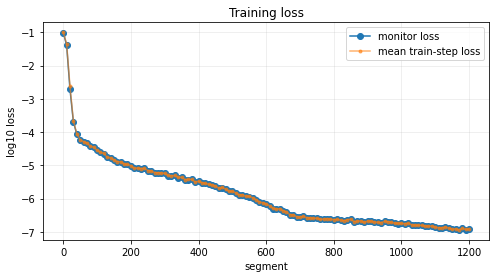

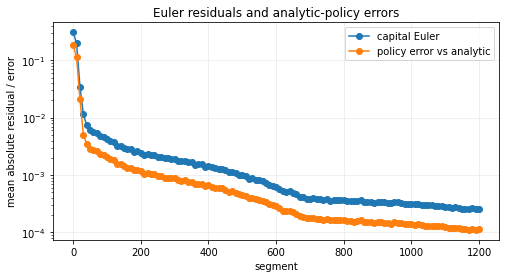

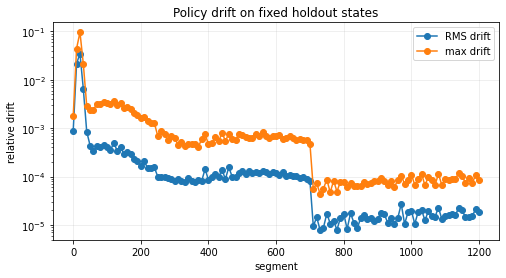

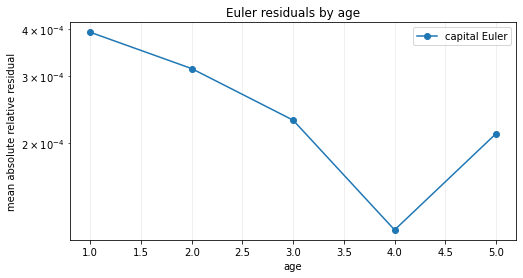

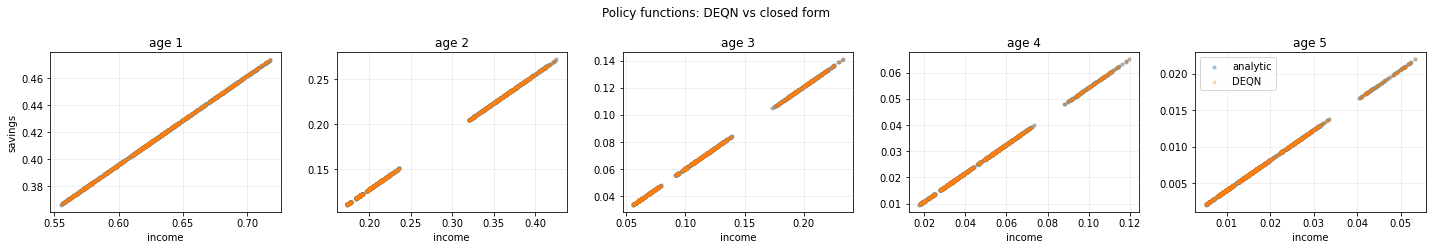

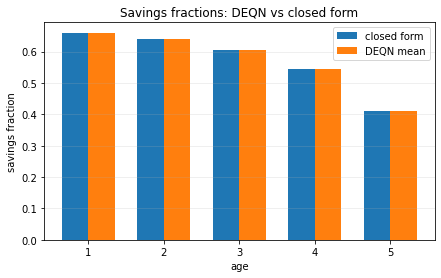

Savings-fraction comparison


,age,closed_form,DEQN_mean,abs_error
0,1,0.659999,0.660002,0.000003
1,2,0.639393,0.639402,0.000010
2,3,0.605211,0.605222,0.000010
3,4,0.543379,0.543384,0.000005
4,5,0.411765,0.411763,0.000002


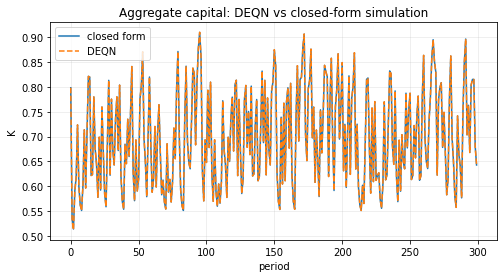

Aggregate-capital path error relative to closed form
  mean = 2.029e-04
  max  = 5.140e-03



Ergodic-mean prices under the closed-form policy
  gross return r = 0.689   (below one: depreciation is 50% or 90% per period)
  wage         w = 0.630
  capital      K = 0.709


In [12]:
# ============================================================
# Simple plots and analytic validation
# ============================================================
if len(history["segment"]) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["segment"], np.log10(np.maximum(history["loss"], 1e-30)), marker="o", label="monitor loss")
    ax.plot(history["segment"], np.log10(np.maximum(history["train_loss"], 1e-30)), marker=".", alpha=0.6, label="mean train-step loss")
    ax.set_xlabel("segment")
    ax.set_ylabel("log10 loss")
    ax.set_title("Training loss")
    ax.grid(alpha=0.25)
    ax.legend()
    savefig(fig, "olg6_loss.pdf")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["segment"], history["mean_abs_euler_capital"], marker="o", label="capital Euler")
    ax.plot(history["segment"], history["mean_abs_policy_error"], marker="o", label="policy error vs analytic")
    ax.set_yscale("log")
    ax.set_xlabel("segment")
    ax.set_ylabel("mean absolute residual / error")
    ax.set_title("Euler residuals and analytic-policy errors")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["segment"], history["policy_drift_rms"], marker="o", label="RMS drift")
    ax.plot(history["segment"], history["policy_drift_max"], marker="o", label="max drift")
    ax.set_yscale("log")
    ax.set_xlabel("segment")
    ax.set_ylabel("relative drift")
    ax.set_title("Policy drift on fixed holdout states")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()


def plot_residuals_by_age(X, model, max_states=4096):
    X = np.asarray(X, dtype=np.float32)
    if X.shape[0] > max_states:
        idx = np.random.default_rng(SEED + 6161).choice(X.shape[0], size=max_states, replace=False)
        X = X[idx]
    _, comp = compute_residuals(tf.constant(X), model)
    e_cap = np.abs(comp["euler_capital"].numpy())
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(AGES[:-1], np.mean(e_cap, axis=0), marker="o", label="capital Euler")
    ax.set_yscale("log")
    ax.set_xlabel("age")
    ax.set_ylabel("mean absolute relative residual")
    ax.set_title("Euler residuals by age")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()


def plot_policy_against_analytic(X, model, max_states=1024):
    X = np.asarray(X, dtype=np.float32)
    if X.shape[0] > max_states:
        idx = np.random.default_rng(SEED + 7171).choice(X.shape[0], size=max_states, replace=False)
        X = X[idx]
    X_tf = tf.constant(X, dtype=tf.float32)
    income, _, _, _, _, _, _, _, _ = current_income(X_tf)
    rel_policy, frac_policy, a_deqn, a_exact, frac = policy_error_against_analytic(X_tf, model)
    income_np = income[:, :N_CHOICES].numpy()
    a_deqn_np = a_deqn.numpy()
    a_exact_np = a_exact.numpy()

    fig, axes = plt.subplots(1, N_CHOICES, figsize=(4 * N_CHOICES, 3.5), squeeze=False)
    axes = axes[0]
    for j, ax in enumerate(axes):
        ax.scatter(income_np[:, j], a_exact_np[:, j], s=10, marker="o", alpha=0.35, label="analytic")
        ax.scatter(income_np[:, j], a_deqn_np[:, j], s=8, marker="x", alpha=0.35, label="DEQN")
        ax.set_title(f"age {j + 1}")
        ax.set_xlabel("income")
        if j == 0:
            ax.set_ylabel("savings")
        ax.grid(alpha=0.25)
    axes[-1].legend(loc="best")
    fig.suptitle("Policy functions: DEQN vs closed form")
    plt.tight_layout()
    savefig(fig, "olg6_policy_scatter.pdf")
    plt.show()

    mean_frac = np.mean(frac.numpy(), axis=0)
    fig, ax = plt.subplots(figsize=(7, 4))
    width = 0.35
    x = np.arange(1, N_AGES)
    ax.bar(x - width / 2, BETA_VEC, width, label="closed form")
    ax.bar(x + width / 2, mean_frac, width, label="DEQN mean")
    ax.set_xlabel("age")
    ax.set_ylabel("savings fraction")
    ax.set_title("Savings fractions: DEQN vs closed form")
    ax.grid(alpha=0.25, axis="y")
    ax.legend()
    savefig(fig, "olg6_savings_bars.pdf")
    plt.show()

    print("Savings-fraction comparison")
    rows = []
    for j in range(N_CHOICES):
        rows.append({
            "age": j + 1,
            "closed_form": BETA_VEC[j],
            "DEQN_mean": mean_frac[j],
            "abs_error": abs(mean_frac[j] - BETA_VEC[j]),
        })
    display(pd.DataFrame(rows))


def compare_exact_and_deqn_dynamics(model, n_tracks=1, n_steps=300, seed_offset=8181):
    local_rng = np.random.default_rng(SEED + seed_offset)
    X_deqn = sample_feasible_initial_states(n_tracks, seed_offset=seed_offset)
    X_exact = X_deqn.copy()
    K_deqn = []
    K_exact = []
    for _ in range(n_steps):
        K_deqn.append(np.sum(X_deqn[:, 1:1 + N_AGES], axis=1))
        K_exact.append(np.sum(X_exact[:, 1:1 + N_AGES], axis=1))
        z_cur = X_deqn[:, 0].astype(int)
        u = local_rng.random(n_tracks)
        z_next = np.sum(u[:, None] > PI_CUM[z_cur], axis=1).astype(np.float32)
        X_deqn = one_step_transition(X_deqn, model, z_next)
        X_exact = one_step_transition_analytic(X_exact, z_next)
    return np.asarray(K_deqn), np.asarray(K_exact)


plot_residuals_by_age(X_eval_sim, model)
plot_policy_against_analytic(X_eval_sim, model)

K_deqn, K_exact = compare_exact_and_deqn_dynamics(model)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_exact[:, 0], label="closed form")
ax.plot(K_deqn[:, 0], linestyle="--", label="DEQN")
ax.set_title("Aggregate capital: DEQN vs closed-form simulation")
ax.set_xlabel("period")
ax.set_ylabel("K")
ax.grid(alpha=0.25)
ax.legend()
savefig(fig, "olg6_K_path.pdf")
plt.show()

rel_K_error = np.abs(K_deqn - K_exact) / np.maximum(np.abs(K_exact), EPS)
print("Aggregate-capital path error relative to closed form")
print(f"  mean = {np.mean(rel_K_error):.3e}")
print(f"  max  = {np.max(rel_K_error):.3e}")


# ------------------------------------------------------------
# Ergodic-mean prices under the closed-form policy
# ------------------------------------------------------------
def ergodic_prices_closed_form(n_periods=20_000, burn_in=500, seed_offset=9191):
    local_rng = np.random.default_rng(SEED + seed_offset)
    X = sample_feasible_initial_states(1, seed_offset=seed_offset)
    r_path, w_path, K_path = [], [], []
    for t in range(n_periods):
        K, r, w, Y, eta, depr = state_prices(tf.constant(X))
        if t >= burn_in:
            r_path.append(float(r[0, 0])); w_path.append(float(w[0, 0])); K_path.append(float(K[0, 0]))
        z_next = np.sum(local_rng.random(1)[:, None] > PI_CUM[X[:, 0].astype(int)], axis=1).astype(np.float32)
        X = one_step_transition_analytic(X, z_next)
    return np.mean(r_path), np.mean(w_path), np.mean(K_path)


r_bar, w_bar, K_bar = ergodic_prices_closed_form()
print("\nErgodic-mean prices under the closed-form policy")
print(f"  gross return r = {r_bar:.3f}   (below one: depreciation is 50% or 90% per period)")
print(f"  wage         w = {w_bar:.3f}")
print(f"  capital      K = {K_bar:.3f}")


## How to use the notebook

`RUN_MODE = "smoke"` is a short run for checking the code, `"teaching"` the run whose outputs are stored here, and `"production"` the episode scale of AGS (2022), Appendix A.8. The hidden layers are 100 and 50 units at the teaching and production presets and 64 and 32 at smoke.

The loss uses only the Euler equations; the closed-form savings rates appear only in the validation tables and plots after training. The two notebooks `04_01` and `04_04` differ in one thing, where the training states come from, and both report residuals on both kinds of out-of-sample states.